In [2]:
import warnings
#warnings.simplefilter(action='ignore')
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from pycaret.utils import version
version()

'3.3.2'

# Prepare the data

## Load the dataset

In [3]:
import pandas as pd
import os
from pycaret.classification import setup
target = 'is_alive?'
df = pd.read_csv("data/INA_dataset_4_pycaret.csv", index_col=0)
df

,gender,age_group,base_pathology_area,BiPadLSTM_0,BiPadLSTM_1,BiPadLSTM_2,BiPadLSTM_3,BiPadLSTM_4,BiPadLSTM_5,BiPadLSTM_6,...,BiPadLSTM_591,BiPadLSTM_592,BiPadLSTM_593,BiPadLSTM_594,BiPadLSTM_595,BiPadLSTM_596,BiPadLSTM_597,BiPadLSTM_598,BiPadLSTM_599,is_alive?
2,1,0,1,-0.017039,0.068211,-0.016360,0.036773,-0.051815,0.083326,-0.008021,...,-0.080256,0.158126,-0.000419,0.005559,0.090299,-0.118068,-0.087052,0.023185,-0.159093,0
3,0,0,1,-0.003374,0.047119,-0.006044,-0.033737,-0.043336,0.046474,-0.010927,...,-0.086919,0.162371,-0.001530,0.022880,0.100254,-0.132805,-0.088320,0.017646,-0.151688,0
4,1,0,1,-0.622606,0.605318,-0.037552,0.091455,-0.752027,0.190134,-0.009048,...,-0.557988,0.835834,-0.673291,0.070169,0.631869,-0.861164,0.931036,0.311230,-0.120694,0
5,0,0,2,-0.006048,0.070000,-0.013080,0.011640,-0.016862,0.095633,0.003275,...,-0.029550,0.121646,0.005617,-0.008081,0.097748,-0.152555,-0.090423,-0.008958,-0.139001,0
7,1,0,3,-0.004544,0.079774,-0.008907,0.019688,-0.047842,0.054314,-0.015483,...,-0.084716,0.080694,-0.001689,0.021989,0.092208,-0.069863,-0.013569,0.017238,-0.086355,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1938,1,0,1,-0.045365,0.093868,-0.009118,0.034092,-0.084472,0.111526,0.008917,...,-0.130862,0.204624,-0.025740,0.014662,0.151791,-0.195387,0.212125,0.053903,-0.105885,0
1948,1,0,1,-0.599408,0.618176,-0.027336,0.088247,-0.763667,0.301425,-0.005065,...,-0.438109,0.822165,0.067514,0.060021,0.516512,-0.863615,0.686108,0.187934,-0.066046,0
1949,1,0,1,-0.452742,0.522530,-0.061684,0.100106,-0.577649,0.233787,0.005751,...,-0.215886,0.446247,0.188700,0.114914,0.206202,-0.519270,0.556947,0.091698,-0.102539,0
1950,1,2,1,-0.644357,0.691805,-0.012064,0.082685,-0.801943,0.300982,-0.003249,...,-0.413440,0.813661,0.280776,0.089897,0.500479,-0.800604,0.584980,0.154260,-0.163057,0


# Best Model

In [4]:
from pycaret.classification import *
from sklearn.metrics import brier_score_loss
# Set up PyCaret environment with Random Oversampled data
clf = setup(data=df, target=target, fold=5, session_id=123,use_gpu=False, fix_imbalance = True, verbose=False)
# aggiungi la metrica
add_metric(
    id='brier',
    name='Brier Score',
    score_func=brier_score_loss,
    target='pred_proba',
    greater_is_better=False
)
# Compare models and select the best one
bests = clf.compare_models(n_select=20, round= 3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score,TT (Sec)
catboost,CatBoost Classifier,0.929,0.939,0.690,0.555,0.612,0.573,0.579,0.055,12.392
gbc,Gradient Boosting Classifier,0.926,0.936,0.665,0.543,0.592,0.552,0.559,0.057,3.138
lightgbm,Light Gradient Boosting Machine,0.926,0.925,0.617,0.549,0.573,0.533,0.539,0.066,0.734
qda,Quadratic Discriminant Analysis,0.919,0.761,0.000,0.000,0.000,0.000,0.000,0.081,0.088
dummy,Dummy Classifier,0.919,0.500,0.000,0.000,0.000,0.000,0.000,0.250,0.082
ada,Ada Boost Classifier,0.914,0.913,0.663,0.474,0.550,0.504,0.515,0.146,0.646
dt,Decision Tree Classifier,0.909,0.722,0.499,0.443,0.468,0.419,0.420,0.091,0.312
et,Extra Trees Classifier,0.908,0.889,0.569,0.448,0.499,0.449,0.454,0.066,0.056
svm,SVM - Linear Kernel,0.906,0.927,0.630,0.526,0.504,0.460,0.497,0.000,0.040
rf,Random Forest Classifier,0.906,0.901,0.509,0.430,0.462,0.411,0.415,0.067,0.342


In [5]:
for model in bests:
    pred = clf.predict_model(
        model,
        data=get_config('test'),
        probability_threshold=0.3
    )

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score
0,CatBoost Classifier,0.9260,0.9521,0.7778,0.5283,0.6292,0.5898,0.6034,0.0460


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score
0,Gradient Boosting Classifier,0.9215,0.9528,0.8056,0.5088,0.6237,0.5823,0.6015,0.0476


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score
0,Light Gradient Boosting Machine,0.9350,0.9541,0.6667,0.5854,0.6234,0.5880,0.5894,0.0495


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score
0,Quadratic Discriminant Analysis,0.9081,0.5404,0.1111,0.3077,0.1633,0.1258,0.1444,0.0919


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score
0,Dummy Classifier,0.0807,0.5000,1.0000,0.0807,0.1494,0.0000,0.0000,0.2500


...

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score
0,Logistic Regression,0.8206,0.9530,0.9167,0.3000,0.4521,0.3762,0.4606,0.0813


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score
0,K Neighbors Classifier,0.8565,0.8898,0.8889,0.3478,0.5000,0.4344,0.4999,0.0970


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score
0,Ridge Classifier,0.8587,0.8725,0.8889,0.3516,0.5039,0.4390,0.5036,0.1413


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score
0,Naive Bayes,0.7152,0.8215,0.9444,0.2138,0.3487,0.2500,0.3637,0.2848


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Brier Score
0,Linear Discriminant Analysis,0.7534,0.7171,0.7222,0.2063,0.3210,0.2235,0.2894,0.2084


In [6]:
from pycaret.classification import pull
regression_results = pull()
print(regression_results.to_latex())

\begin{tabular}{llrrrrrrrr}
\toprule
 & Model & Accuracy & AUC & Recall & Prec. & F1 & Kappa & MCC & Brier Score \\
\midrule
0 & Linear Discriminant Analysis & 0.753400 & 0.717100 & 0.722200 & 0.206300 & 0.321000 & 0.223500 & 0.289400 & 0.208400 \\
\bottomrule
\end{tabular}



CatBoostClassifier(border_count=254, random_state=123, task_type='CPU', verbose=False)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

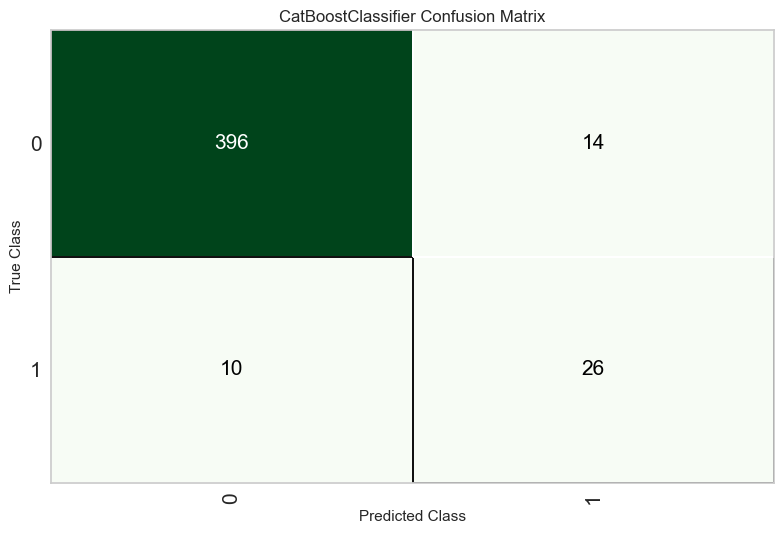

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['gender', 'age_group',
                                             'base_pathology_area',
                                             'BiPadLSTM_0', 'BiPadLSTM_1',
                                             'BiPadLSTM_2', 'BiPadLSTM_3',
                                             'BiPadLSTM_4', 'BiPadLSTM_5',
                                             'BiPadLSTM_6', 'BiPadLSTM_7',
                                             'BiPadLSTM_8', 'BiPadLSTM_9',
                                             'BiPadLSTM_10', 'BiPadLSTM_11',
                                             'BiPadLSTM_12', 'BiPadLSTM_13',...
                                    transformer=FixImbalancer(estimator=SMOTE(k_neighbors=5,
                                                                              random_state=123,
                

In [7]:
# Print the best model
model = bests[0]
print(model)

# Evaluate the model using built-in visualizations
clf.evaluate_model(model)

# Plot the ROC AUC curve
clf.plot_model(model, plot = 'confusion_matrix')

# Finalize the logistic regression model
fin_model = clf.finalize_model(model)
print(fin_model)

# Create an interactive dashboard for the logistic regression model
#clf.dashboard(fin_model)

## Show the best pipeline model

In [8]:
fin_model

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['gender', 'age_group',
                                             'base_pathology_area',
                                             'BiPadLSTM_0', 'BiPadLSTM_1',
                                             'BiPadLSTM_2', 'BiPadLSTM_3',
                                             'BiPadLSTM_4', 'BiPadLSTM_5',
                                             'BiPadLSTM_6', 'BiPadLSTM_7',
                                             'BiPadLSTM_8', 'BiPadLSTM_9',
                                             'BiPadLSTM_10', 'BiPadLSTM_11',
                                             'BiPadLSTM_12', 'BiPadLSTM_13',...
                                    transformer=FixImbalancer(estimator=SMOTE(k_neighbors=5,
                                                                              random_state=123,
                                                                              sampling_strategy='auto')))),
                ('clean_column_names',
                 TransformerWrapper(exclude=None, include=None,
                                    transformer=CleanColumnNames(match='[\\]\\[\\,\\{\\}\\"\\:]+'))),
                ('actual_estimator',
                 CatBoostClassifier(border_count=254, random_state=123, task_type='CPU', verbose=False))],
         verbose=False)

# Reuse optimal classifier in CV


🚀 Inizio cross-validation...



Folds:   0%|          | 0/5 [00:00<?, ?it/s]


📊 Risultati medi su 5 fold:
🧮 MCC:     0.6008 ± 0.0329
📈 AUC:     0.9466 ± 0.0152
🎯 Accuracy:0.9340 ± 0.0063
⚖️ Precision:0.5813 ± 0.0453
🔁 Recall:  0.7000 ± 0.0808
🧪 F1-score:0.6308 ± 0.0276

🧩 Confusion Matrix finale (aggregata):
[[1304   62]
 [  36   84]]


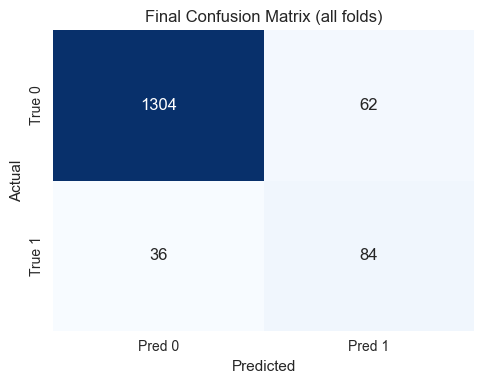

$0.6008\pm0.0329$ & $0.9466\pm0.0152$ & $0.9340\pm0.0063$ & $0.5813\pm0.0453$ & $0.7000\pm0.0808$ & $0.6308\pm0.0276$ & [[1304   62]
 [  36   84]] \\


In [9]:
from tqdm.notebook import tqdm
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    matthews_corrcoef, confusion_matrix, accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score)
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier
from pycaret.classification import get_config
mcc_scores = []
acc_scores = []
rocauc_scores = []
prec_scores = []
recall_scores = []
f1_scores = []
y_valid_all = []
y_pred_all = []

y = df[target]
x = df.drop(columns=[target])
print("\n🚀 Inizio cross-validation...\n")
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
pbar = tqdm(skf.split(x, y), total=n_splits, desc="Folds")

for fold, (train_idx, valid_idx) in enumerate(pbar):
    X_train, X_valid = x.iloc[train_idx], x.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # clone the pre-processing pipeline (unfitted)
    pipeline = clone(get_config("pipeline"))
    # fit the pre-processing pipeline and transform train and test data
    X_t, y_t = pipeline.fit_transform(X_train, y_train)
    X_tt  = pipeline.transform(X_valid)
    # instantiate an unfitted model (the best)
    model = clone(bests[0])
    #model = VotingClassifier(estimators=[('gc', clone(bests[0])), ('lr', clone(bests[1])), ('nb2', clone(bests[12]))], voting='soft')
    model.fit(X_t, y_t)

    y_pred_proba = model.predict_proba(X_tt)[:, 1]  # probability of class 1
    y_pred_labels = (y_pred_proba > 0.5).astype(int)

    y_true = y_valid.to_numpy()

    # Metrics
    mcc = matthews_corrcoef(y_true, y_pred_labels)
    acc = accuracy_score(y_true, y_pred_labels)
    rocauc = roc_auc_score(y_true, y_pred_proba)
    prec = precision_score(y_true, y_pred_labels)
    recall = recall_score(y_true, y_pred_labels)
    f1 = f1_score(y_true, y_pred_labels)

    # Salva
    mcc_scores.append(mcc)
    acc_scores.append(acc)
    rocauc_scores.append(rocauc)
    prec_scores.append(prec)
    recall_scores.append(recall)
    f1_scores.append(f1)
    y_valid_all.extend(y_valid)
    y_pred_all.extend(y_pred_labels)

    # 🧠 Aggiorna tqdm
    pbar.set_postfix({
        "Fold": fold + 1,
        "MCC": f"{mcc:.4f}",
        "AUC": f"{rocauc:.4f}",
        "Acc": f"{acc:.4f}",
        "F1": f"{f1:.4f}"
    })

# Final confusion matrix
cm_final = confusion_matrix(y_valid_all, y_pred_all)

print(f"\n📊 Risultati medi su {n_splits} fold:")
print(f"🧮 MCC:     {np.mean(mcc_scores):.4f} ± {np.std(mcc_scores):.4f}")
print(f"📈 AUC:     {np.mean(rocauc_scores):.4f} ± {np.std(rocauc_scores):.4f}")
print(f"🎯 Accuracy:{np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"⚖️ Precision:{np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"🔁 Recall:  {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"🧪 F1-score:{np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

print(f"\n🧩 Confusion Matrix finale (aggregata):\n{cm_final}")

plt.figure(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.title('Final Confusion Matrix (all folds)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
print(f"${np.mean(mcc_scores):.4f}\pm{np.std(mcc_scores):.4f}$", end=' & ')
print(f"${np.mean(rocauc_scores):.4f}\pm{np.std(rocauc_scores):.4f}$", end=' & ')
print(f"${np.mean(acc_scores):.4f}\pm{np.std(acc_scores):.4f}$", end=' & ')
print(f"${np.mean(prec_scores):.4f}\pm{np.std(prec_scores):.4f}$", end=' & ')
print(f"${np.mean(recall_scores):.4f}\pm{np.std(recall_scores):.4f}$", end=' & ')
print(f"${np.mean(f1_scores):.4f}\pm{np.std(f1_scores):.4f}$", end=' & ')
print(f"{cm_final} \\\\")

## SHAP analysis

In [10]:
model

CatBoostClassifier(border_count=254, random_state=123, task_type='CPU', verbose=False)